In [2]:
import pandas as pd
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
import math
import itertools

import subprocess

/tmp/ipykernel_1514884/1326961635.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [41]:
blocks_sign = pd.read_csv('../signficant_intersection/sign_blocks_union_first_last_gen_BH_final.csv')

In [42]:
blocks_sign.gen.unique()

array(['first_gen', 'first_gen,last_gen', 'last_gen'], dtype=object)

In [43]:
blocks_sign = blocks_sign[blocks_sign['gen'].isin(['first_gen,last_gen', 'last_gen'])]

In [44]:
dict_blocks = '../key_files/blocks_snpsid_dict.pkl'

with open(dict_blocks, 'rb') as file:
    dict_blocks = pickle.load(file)

reverse_mapping = {item: key for key, values in dict_blocks.items() for item in values}

In [45]:
snps_dict = pd.read_csv('../key_files/var_pos_grenenet.csv')

In [46]:
snps_dict['block'] = snps_dict['id'].map(reverse_mapping)

In [50]:
snps_dict_filt = snps_dict[snps_dict['block'].isin(['2_1265'])] #blocks_sign['block'].values

In [53]:
awk_conditions = []

for i in ['2_1265']: #blocks_sign['block'].values:
    start_idx = snps_dict[snps_dict['block'].isin([i])].index.values[0] + 2  # Adjusting the start index
    end_idx = snps_dict[snps_dict['block'].isin([i])].index.values[-1] + 2 # Adjusting the end index
    awk_conditions.append(f"NR >= {start_idx} && NR <= {end_idx}")  # Convert integers to strings inside f-string


# Join the conditions with ' || ' to match the awk syntax
awk_filter = ' || '.join(awk_conditions)

# Construct the final awk command
awk_command = f"awk '{awk_filter}' ../baypass_first_gen/merged_hapFIRE_allele_frequency_indexed.csv > af_blocks_sign.csv"

# Run the command using subprocess
subprocess.run(awk_command, shell=True, check=True)

CompletedProcess(args="awk 'NR >= 1181471 && NR <= 1181493' ../baypass_first_gen/merged_hapFIRE_allele_frequency_indexed.csv > af_blocks_sign.csv", returncode=0)

In [79]:
af_blocks_sign = pd.read_csv('af_blocks_sign.csv',header=None)

In [80]:
usecols = pd.read_csv('../baypass_first_gen/merged_hapFIRE_allele_frequency_indexed.csv',nrows =1).columns 
af_blocks_sign.columns = usecols

In [81]:
snps_dict = pd.read_csv('../key_files/var_pos_grenenet.csv')
snps_dict['block'] = snps_dict['id'].map(reverse_mapping)

In [82]:
#snps_dict_filt = snps_dict[snps_dict['block'].isin(blocks_sign['block'].values)]
snps_dict_filt = snps_dict[snps_dict['block'].isin(['2_1265'])] #blocks_sign['block'].values

In [83]:
snps_dict_filt = snps_dict_filt.reset_index(drop=True)

causal = pd.concat([af_blocks_sign, snps_dict_filt],axis=1)

In [84]:
causal_det = causal[['pos', 'chrom', 'maf05filter', 'total_alleles05filter_firstgen', 'block']].copy()


In [85]:
#causal = causal[causal['total_alleles05filter_firstgen'].notna()]
causal =causal.drop(['pos', 'chrom', 'maf05filter', 'total_alleles05filter_firstgen', 'total_alleles05filter_lastgen', 'block'],axis=1).set_index('id')

first_gen = pd.read_csv('../key_files/generation_1_sample_names.txt',header=None)[0]

final_gen = pd.read_csv('../key_files/final_gen.csv')['sample_name']

In [86]:
causal_last_gen = causal[first_gen]

In [87]:
snps_cam5 = snps_dict_filt[snps_dict_filt['block'] == '2_1265']['id'].values

#causal_last_gen = causal_last_gen[causal_last_gen.index.isin(snps_cam5)]

In [88]:
snps_cam5

array(['2_11533904', '2_11533924', '2_11533937', '2_11533944',
       '2_11533991', '2_11533994', '2_11534005', '2_11534015',
       '2_11534022', '2_11534023', '2_11534030', '2_11534048',
       '2_11534063', '2_11534092', '2_11534094', '2_11534099',
       '2_11534102', '2_11534143', '2_11534161', '2_11534165',
       '2_11534224', '2_11534244', '2_11534263'], dtype=object)

In [64]:
snps_cam5

array(['2_11533904', '2_11533924', '2_11533937', '2_11533944',
       '2_11533991', '2_11533994', '2_11534005', '2_11534015',
       '2_11534022', '2_11534023', '2_11534030', '2_11534048',
       '2_11534063', '2_11534092', '2_11534094', '2_11534099',
       '2_11534102', '2_11534143', '2_11534161', '2_11534165',
       '2_11534224', '2_11534244', '2_11534263'], dtype=object)

In [92]:
pop_structure_first_gen = pd.read_csv('../lmm_meixi/pop_structure_first_gen.csv')

In [93]:
p0_average_seed_mix = pd.read_csv('../key_files/p0_average_seed_mix.csv')
snps_dict = pd.read_csv('../key_files/var_pos_grenenet.csv')
p0_average_seed_mix = pd.concat([p0_average_seed_mix,snps_dict ], axis=1)

In [94]:
p0_average_seed_mix = p0_average_seed_mix[p0_average_seed_mix['id'].isin(causal_last_gen.index)]

In [95]:
causal_last_gen.index

Index(['2_11533904', '2_11533924', '2_11533937', '2_11533944', '2_11533991',
       '2_11533994', '2_11534005', '2_11534015', '2_11534022', '2_11534023',
       '2_11534030', '2_11534048', '2_11534063', '2_11534092', '2_11534094',
       '2_11534099', '2_11534102', '2_11534143', '2_11534161', '2_11534165',
       '2_11534224', '2_11534244', '2_11534263'],
      dtype='object', name='id')

In [96]:
p0_average_seed_mix = p0_average_seed_mix.reset_index()

In [97]:
#af_blocks_sign = af_blocks_sign.drop(['Unnamed: 745', '0'],axis=1)

In [98]:
causal_last_gen

,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,1_1_10,...,60_1_3,60_1_4,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12
id,,,,,,,,,,,,,,,,,,,,,
2_11533904,0.044251,0.039594,0.029825,0.073591,0.032463,0.049082,0.043163,0.066333,0.069596,0.071941,...,0.009054,0.117680,0.077498,0.189218,0.035397,0.072443,0.349814,0.071965,0.307933,0.088219
2_11533924,0.032903,0.026260,0.023733,0.054389,0.025344,0.036939,0.034201,0.050304,0.061752,0.058057,...,0.004831,0.114832,0.046805,0.155605,0.033252,0.067612,0.343880,0.068270,0.305561,0.085431
2_11533937,0.043572,0.038390,0.028944,0.069723,0.031766,0.047597,0.042314,0.064441,0.067077,0.070456,...,0.008829,0.063839,0.077403,0.133840,0.004321,0.072120,0.345257,0.071445,0.243393,0.051130
2_11533944,0.002210,0.007568,0.011313,0.003052,0.003019,0.002865,0.012815,0.006365,0.003571,0.002193,...,0.000705,0.042953,0.002147,0.001235,0.000092,0.002200,0.001713,0.002553,0.000778,0.001552
2_11533991,0.044251,0.039594,0.029825,0.073591,0.032463,0.049082,0.043163,0.066333,0.069596,0.071941,...,0.009054,0.117680,0.077498,0.189218,0.035397,0.072443,0.349814,0.071965,0.307933,0.088219
2_11533994,0.044251,0.039594,0.029825,0.073591,0.032463,0.049082,0.043163,0.066333,0.069596,0.071941,...,0.009054,0.117680,0.077498,0.189218,0.035397,0.072443,0.349814,0.071965,0.307933,0.088219
2_11534005,0.001150,0.001083,0.001588,0.005116,0.001340,0.001293,0.001772,0.001797,0.001581,0.001625,...,0.004006,0.000224,0.000241,0.000446,0.000452,0.005465,0.001747,0.000494,0.000571,0.000806
2_11534015,0.044251,0.039594,0.029825,0.073591,0.032463,0.049082,0.043163,0.066333,0.069596,0.071941,...,0.009054,0.117680,0.077498,0.189218,0.035397,0.072443,0.349814,0.071965,0.307933,0.088219
2_11534022,0.044251,0.039594,0.029825,0.073591,0.032463,0.049082,0.043163,0.066333,0.069596,0.071941,...,0.009054,0.117680,0.077498,0.189218,0.035397,0.072443,0.349814,0.071965,0.307933,0.088219


In [99]:
delta_p = causal_last_gen.subtract(p0_average_seed_mix.set_index('id')['0'], axis=0)

In [100]:
delta_p

,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,1_1_10,...,60_1_3,60_1_4,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12
id,,,,,,,,,,,,,,,,,,,,,
2_11533904,-0.021280,-0.025936,-0.035706,0.008061,-0.033067,-0.016449,-0.022368,0.000802,0.004066,0.006410,...,-0.056476,0.052150,0.011968,0.123687,-0.030134,0.006912,0.284283,0.006434,0.242403,0.022689
2_11533924,-0.011620,-0.018263,-0.020789,0.009866,-0.019179,-0.007584,-0.010322,0.005781,0.017229,0.013534,...,-0.039691,0.070309,0.002282,0.111082,-0.011271,0.023089,0.299358,0.023747,0.261038,0.040908
2_11533937,-0.015416,-0.020598,-0.030044,0.010735,-0.027222,-0.011391,-0.016674,0.005453,0.008089,0.011468,...,-0.050159,0.004851,0.018415,0.074852,-0.054667,0.013132,0.286269,0.012457,0.184405,-0.007858
2_11533944,-0.006667,-0.001309,0.002436,-0.005825,-0.005858,-0.006012,0.003938,-0.002512,-0.005306,-0.006684,...,-0.008171,0.034076,-0.006730,-0.007642,-0.008785,-0.006677,-0.007164,-0.006324,-0.008099,-0.007325
2_11533991,-0.021280,-0.025936,-0.035706,0.008061,-0.033067,-0.016449,-0.022368,0.000802,0.004066,0.006410,...,-0.056476,0.052150,0.011968,0.123687,-0.030134,0.006912,0.284283,0.006434,0.242403,0.022689
2_11533994,-0.021280,-0.025936,-0.035706,0.008061,-0.033067,-0.016449,-0.022368,0.000802,0.004066,0.006410,...,-0.056476,0.052150,0.011968,0.123687,-0.030134,0.006912,0.284283,0.006434,0.242403,0.022689
2_11534005,-0.007810,-0.007877,-0.007372,-0.003844,-0.007620,-0.007667,-0.007188,-0.007163,-0.007379,-0.007335,...,-0.004953,-0.008736,-0.008719,-0.008514,-0.008508,-0.003495,-0.007213,-0.008466,-0.008388,-0.008154
2_11534015,-0.021280,-0.025936,-0.035706,0.008061,-0.033067,-0.016449,-0.022368,0.000802,0.004066,0.006410,...,-0.056476,0.052150,0.011968,0.123687,-0.030134,0.006912,0.284283,0.006434,0.242403,0.022689
2_11534022,-0.021280,-0.025936,-0.035706,0.008061,-0.033067,-0.016449,-0.022368,0.000802,0.004066,0.006410,...,-0.056476,0.052150,0.011968,0.123687,-0.030134,0.006912,0.284283,0.006434,0.242403,0.022689


In [72]:
#pcs = pd.read_csv('../key_files/pca_greneNet_final_v1.1_LDpruned.recode', sep = ' ',header=None )

In [31]:
#pcs.iloc[:, 2:].to_csv('20pcs.csv',index=None)

In [101]:
pop_structure_first_gen.index = delta_p.columns

In [74]:
corr_results = {}
for i in delta_p.index:
    corr_value = delta_p.loc[i, :].corr(pop_structure_first_gen['PC1'])
    corr_results[i] = [corr_value]

In [33]:
snps_dict_filt

,id,pos,chrom,maf05filter,total_alleles05filter_firstgen,total_alleles05filter_lastgen,block
0,1_163688,163688,1,NaN,NaN,NaN,1_22
1,1_163699,163699,1,NaN,NaN,NaN,1_22
2,1_163716,163716,1,1_163716,1_163716,1_163716,1_22
3,1_163740,163740,1,NaN,NaN,NaN,1_22
4,1_163750,163750,1,1_163750,1_163750,1_163750,1_22
...,...,...,...,...,...,...,...
9746,5_21506310,21506310,5,NaN,NaN,NaN,5_2430
9747,5_21506313,21506313,5,NaN,NaN,NaN,5_2430
9748,5_21506369,21506369,5,5_21506369,5_21506369,5_21506369,5_2430
9749,5_21506371,21506371,5,5_21506371,5_21506371,5_21506371,5_2430


In [34]:
pd.DataFrame(corr_results).T.reset_index()

,index,0
0,1_163688,-0.113120
1,1_163699,0.017861
2,1_163716,-0.058986
3,1_163740,-0.045698
4,1_163750,-0.058986
...,...,...
9746,5_21506310,-0.026300
9747,5_21506313,0.231271
9748,5_21506369,0.228213
9749,5_21506371,0.319821


In [35]:
corr_results = pd.DataFrame(corr_results).T.reset_index().merge(snps_dict_filt, left_on = 'index', right_on = 'id')

In [36]:
corr_results.columns = [                         'index',                               'corr',
                                   'id',                            'pos',
                                'chrom',                    'maf05filter',
       'total_alleles05filter_firstgen',  'total_alleles05filter_lastgen',
                                'block']

In [37]:
corr_results

,index,corr,id,pos,chrom,maf05filter,total_alleles05filter_firstgen,total_alleles05filter_lastgen,block
0,1_163688,-0.113120,1_163688,163688,1,NaN,NaN,NaN,1_22
1,1_163699,0.017861,1_163699,163699,1,NaN,NaN,NaN,1_22
2,1_163716,-0.058986,1_163716,163716,1,1_163716,1_163716,1_163716,1_22
3,1_163740,-0.045698,1_163740,163740,1,NaN,NaN,NaN,1_22
4,1_163750,-0.058986,1_163750,163750,1,1_163750,1_163750,1_163750,1_22
...,...,...,...,...,...,...,...,...,...
9746,5_21506310,-0.026300,5_21506310,21506310,5,NaN,NaN,NaN,5_2430
9747,5_21506313,0.231271,5_21506313,21506313,5,NaN,NaN,NaN,5_2430
9748,5_21506369,0.228213,5_21506369,21506369,5,5_21506369,5_21506369,5_21506369,5_2430
9749,5_21506371,0.319821,5_21506371,21506371,5,5_21506371,5_21506371,5_21506371,5_2430


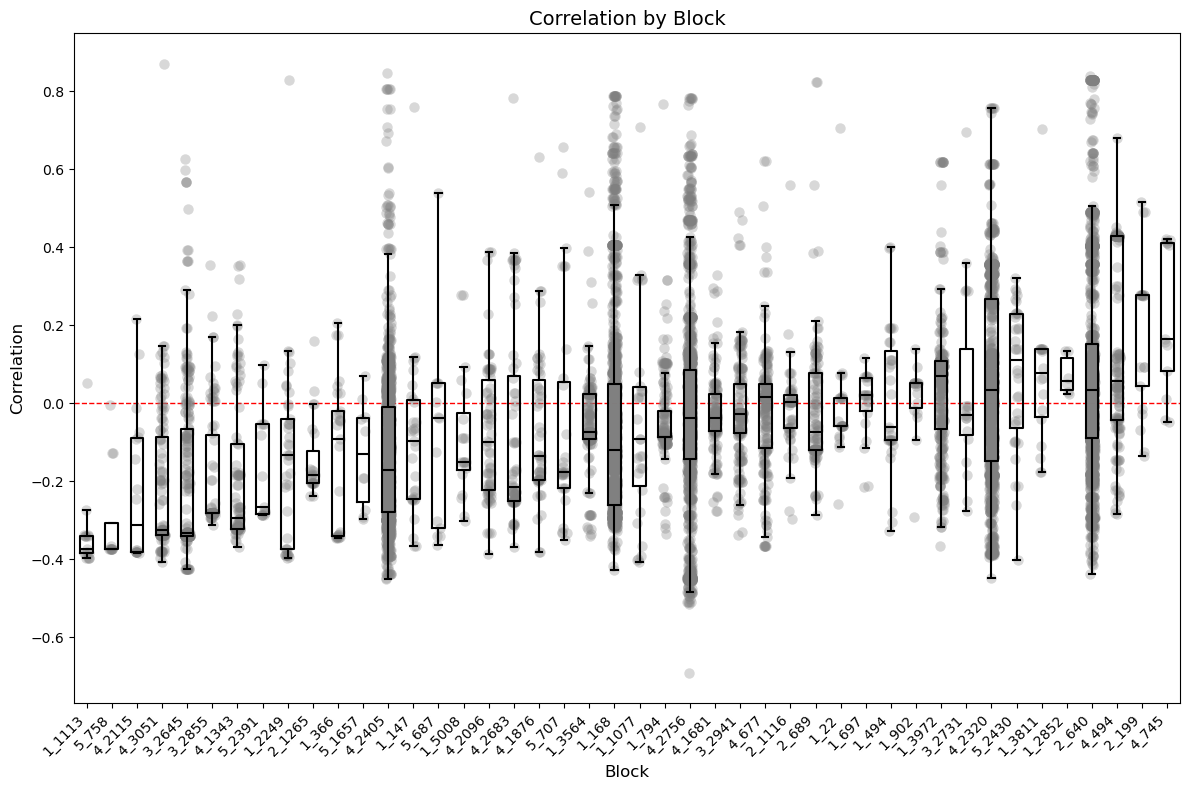

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure corr_results and medians_results are defined and loaded
# (This code assumes `corr_results` and `medians_results` are already calculated)

# Initialize the plot
plt.figure(figsize=(12, 8))

# Plot the points and boxplots
ax = sns.stripplot(
    data=corr_results, 
    y='corr', 
    x='block', 
    color='grey', 
    alpha=0.3, 
    s=7.5, 
    zorder=1, 
    order=medians_results.index
)
sns.boxplot(
    data=corr_results, 
    y='corr', 
    x='block', 
    showfliers=False, 
    color='black', 
    width=0.5, 
    zorder=2, 
    fill=False, 
    order=medians_results.index
)

# Add horizontal dashed lines at 0
plt.axhline(0, linestyle='--', color='red', linewidth=1, zorder=0)

# Rotate x-ticks for readability
plt.xticks(rotation=45, ha='right')

# Set axis labels and title
plt.xlabel('Block', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.title('Correlation by Block', fontsize=14)

plt.tight_layout()
plt.show()


In [215]:
corr_results.groupby('block')[0].mean().reset_index()

,block,0
0,1_1077,-0.046016
1,1_1113,-0.339056
2,1_147,-0.094575
3,1_168,-0.048401
4,1_22,-0.008642
5,1_2249,-0.145737
6,1_2852,0.072476
7,1_3564,-0.050939
8,1_366,-0.140177
9,1_3811,0.068902


In [75]:
snps_cam5

array(['2_11533904', '2_11533924', '2_11533937', '2_11533944',
       '2_11533991', '2_11533994', '2_11534005', '2_11534015',
       '2_11534022', '2_11534023', '2_11534030', '2_11534048',
       '2_11534063', '2_11534092', '2_11534094', '2_11534099',
       '2_11534102', '2_11534143', '2_11534161', '2_11534165',
       '2_11534224', '2_11534244', '2_11534263'], dtype=object)

In [76]:
delta_p

,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,1_1_10,...,60_1_3,60_1_4,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12
id,,,,,,,,,,,,,,,,,,,,,
1_163688,0.034802,0.030146,0.020376,0.064143,0.023015,0.039633,0.033714,0.056884,0.060148,0.062492,...,-0.000395,0.108232,0.068050,0.179769,0.025948,0.062994,0.340365,0.062516,0.298484,0.078771
1_163699,0.025033,0.018390,0.015863,0.046519,0.017474,0.029069,0.026330,0.042434,0.053882,0.050187,...,-0.003039,0.106962,0.038934,0.147734,0.025382,0.059741,0.336010,0.060399,0.297690,0.077561
1_163716,-0.071286,-0.076468,-0.085913,-0.045135,-0.083092,-0.067261,-0.072544,-0.050417,-0.047781,-0.044401,...,-0.106029,-0.051019,-0.037455,0.018982,-0.110537,-0.042737,0.230399,-0.043412,0.128536,-0.063728
1_163740,-0.002238,0.003121,0.006865,-0.001395,-0.001429,-0.001583,0.008368,0.001917,-0.000877,-0.002255,...,-0.003742,0.038505,-0.002301,-0.003213,-0.004355,-0.002248,-0.002735,-0.001895,-0.003670,-0.002896
1_163750,-0.070607,-0.075264,-0.085033,-0.041267,-0.082394,-0.065776,-0.071695,-0.048525,-0.045262,-0.042917,...,-0.105804,0.002823,-0.037359,0.074360,-0.079461,-0.042415,0.234956,-0.042893,0.193075,-0.026639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5_21506310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5_21506313,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5_21506369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
delta_p_cam5 = delta_p[delta_p.index.isin(snps_cam5)]

In [103]:
delta_p_cam5.T

id,2_11533904,2_11533924,2_11533937,2_11533944,2_11533991,2_11533994,2_11534005,2_11534015,2_11534022,2_11534023,...,2_11534092,2_11534094,2_11534099,2_11534102,2_11534143,2_11534161,2_11534165,2_11534224,2_11534244,2_11534263
1_1_1,-0.021280,-0.011620,-0.015416,-0.006667,-0.021280,-0.021280,-0.007810,-0.021280,-0.021280,-0.021280,...,-0.007810,-0.022885,-0.022885,-0.018832,-0.040827,-0.001550,-0.022194,-0.016466,-0.033141,-0.017589
1_1_2,-0.025936,-0.018263,-0.020598,-0.001309,-0.025936,-0.025936,-0.007877,-0.025936,-0.025936,-0.025936,...,-0.007877,-0.022757,-0.022757,-0.018475,-0.045427,-0.004661,-0.026551,-0.016188,-0.033197,-0.017624
1_1_3,-0.035706,-0.020789,-0.030044,0.002436,-0.035706,-0.035706,-0.007372,-0.035706,-0.035706,-0.035706,...,-0.007372,-0.032747,-0.032747,-0.028564,-0.044510,-0.004186,-0.036482,-0.013571,-0.040238,-0.027444
1_1_4,0.008061,0.009866,0.010735,-0.005825,0.008061,0.008061,-0.003844,0.008061,0.008061,0.008061,...,-0.003844,0.007509,0.007509,0.004367,0.000888,-0.004053,0.007283,-0.004292,0.001351,0.004866
1_1_5,-0.033067,-0.019179,-0.027222,-0.005858,-0.033067,-0.033067,-0.007620,-0.033067,-0.033067,-0.033067,...,-0.007620,-0.030534,-0.030534,-0.028021,-0.055219,-0.005255,-0.033955,-0.019458,-0.045557,-0.026987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60_1_8,0.006912,0.023089,0.013132,-0.006677,0.006912,0.006912,-0.003495,0.006912,0.006912,0.006912,...,-0.003495,0.010595,0.010595,0.015030,-0.024705,-0.006438,0.006060,-0.028389,-0.011337,0.016199
60_1_9,0.284283,0.299358,0.286269,-0.007164,0.284283,0.284283,-0.007213,0.284283,0.284283,0.284283,...,-0.007213,0.285877,0.285877,0.289869,0.257501,-0.004758,0.283443,-0.024789,0.265880,0.289829
60_1_10,0.006434,0.023747,0.012457,-0.006324,0.006434,0.006434,-0.008466,0.006434,0.006434,0.006434,...,-0.008466,0.009430,0.009430,0.013572,0.027014,-0.005638,0.005352,0.023944,0.039845,0.014818
60_1_11,0.242403,0.261038,0.184405,-0.008099,0.242403,0.242403,-0.008388,0.242403,0.242403,0.242403,...,-0.008388,0.246011,0.246011,0.250489,0.237022,-0.006528,0.241373,-0.001743,0.248989,0.249703


In [104]:
pop_structure_first_gen.index = delta_p_cam5.T.index

In [105]:
cam5_pop_structure = pd.concat([delta_p_cam5.T, pop_structure_first_gen[['PC1', 'PC2']]],axis=1)

In [106]:
cam5_pop_structure.columns

Index(['2_11533904', '2_11533924', '2_11533937', '2_11533944', '2_11533991',
       '2_11533994', '2_11534005', '2_11534015', '2_11534022', '2_11534023',
       '2_11534030', '2_11534048', '2_11534063', '2_11534092', '2_11534094',
       '2_11534099', '2_11534102', '2_11534143', '2_11534161', '2_11534165',
       '2_11534224', '2_11534244', '2_11534263', 'PC1', 'PC2'],
      dtype='object')

In [107]:
## lineal model with the leading snp cam5 

In [108]:


#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_experimental_sites_era5.csv')

sites_af = pd.Series(cam5_pop_structure.index).str.split('_').str[0].astype(int)

sites_af.name = 'site'

env = sites_af.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

bio1 = env['bio1']

In [109]:
env

,site,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,1,10.743906,21.193924,47.688171,716.659942,32.801716,-11.641011,44.442727,2.111033,11.485406,19.925933,2.111033,856.388686,105.54803,36.146984,32.017410,286.45640,147.922504,215.184498,286.45640
1,1,10.743906,21.193924,47.688171,716.659942,32.801716,-11.641011,44.442727,2.111033,11.485406,19.925933,2.111033,856.388686,105.54803,36.146984,32.017410,286.45640,147.922504,215.184498,286.45640
2,1,10.743906,21.193924,47.688171,716.659942,32.801716,-11.641011,44.442727,2.111033,11.485406,19.925933,2.111033,856.388686,105.54803,36.146984,32.017410,286.45640,147.922504,215.184498,286.45640
3,1,10.743906,21.193924,47.688171,716.659942,32.801716,-11.641011,44.442727,2.111033,11.485406,19.925933,2.111033,856.388686,105.54803,36.146984,32.017410,286.45640,147.922504,215.184498,286.45640
4,1,10.743906,21.193924,47.688171,716.659942,32.801716,-11.641011,44.442727,2.111033,11.485406,19.925933,2.111033,856.388686,105.54803,36.146984,32.017410,286.45640,147.922504,215.184498,286.45640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,60,19.248051,24.553725,60.771600,677.587823,41.499287,1.095998,40.403289,11.972449,27.256729,27.256729,10.795405,486.609187,102.72056,0.151444,100.769692,288.32486,0.540737,0.540737,271.91092
322,60,19.248051,24.553725,60.771600,677.587823,41.499287,1.095998,40.403289,11.972449,27.256729,27.256729,10.795405,486.609187,102.72056,0.151444,100.769692,288.32486,0.540737,0.540737,271.91092
323,60,19.248051,24.553725,60.771600,677.587823,41.499287,1.095998,40.403289,11.972449,27.256729,27.256729,10.795405,486.609187,102.72056,0.151444,100.769692,288.32486,0.540737,0.540737,271.91092
324,60,19.248051,24.553725,60.771600,677.587823,41.499287,1.095998,40.403289,11.972449,27.256729,27.256729,10.795405,486.609187,102.72056,0.151444,100.769692,288.32486,0.540737,0.540737,271.91092


In [110]:
lm = cam5_pop_structure[['2_11534244', 'PC1', 'PC2']]

In [111]:
lm['bio1'] = bio1.values

/tmp/ipykernel_1514884/1562809187.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lm['bio1'] = bio1.values


In [112]:
lm

,2_11534244,PC1,PC2,bio1
1_1_1,-0.033141,-0.002973,0.005532,10.743906
1_1_2,-0.033197,-0.020747,0.013771,10.743906
1_1_3,-0.040238,-0.015614,0.011391,10.743906
1_1_4,0.001351,-0.015802,0.001874,10.743906
1_1_5,-0.045557,-0.023868,0.008038,10.743906
...,...,...,...,...
60_1_8,-0.011337,-0.025411,0.011596,19.248051
60_1_9,0.265880,-0.025633,-0.005403,19.248051
60_1_10,0.039845,-0.024356,-0.031059,19.248051
60_1_11,0.248989,-0.036588,-0.037978,19.248051


In [113]:
lm.columns = ['y', 'PC1', 'PC2', 'bio1']

In [114]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Construct the formula
formula = 'y ~ bio1 + PC1 + PC2'

# Fit the linear model
model = smf.ols(formula, data=lm).fit()

# Print the summary of the model to view the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     10.08
Date:                Mon, 16 Dec 2024   Prob (F-statistic):           2.29e-06
Time:                        07:34:02   Log-Likelihood:                 279.74
No. Observations:                 326   AIC:                            -551.5
Df Residuals:                     322   BIC:                            -536.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0751      0.021     -3.647      0.0

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

# Sample data - replace 'lm' with your actual DataFrame
data = {
    'y': [1, 2, 3, 4, 5],
    'bio1': [1.5, 2.5, 3.5, 4.5, 5.5],
    'PC1': [0.1, 0.2, 0.3, 0.4, 0.5],
    'PC2': [5, 4, 3, 2, 1]
}
lm = pd.DataFrame(data)

# Construct the formula
formula = 'y ~ bio1 + PC1 + PC2'

# Fit the linear model
model = smf.ols(formula, data=lm).fit()

# Print the summary of the model to view the results
print(model.summary())

# If you just want the coefficients
print("Coefficients:")
print(model.params)


In [118]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Construct the formula
formula = 'y ~ bio1 + PC1 + PC2'

# Fit the linear model
model = smf.ols(formula, data=lm).fit()

# Print the summary of the model to view the results
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     10.08
Date:                Mon, 16 Dec 2024   Prob (F-statistic):           2.29e-06
Time:                        07:54:51   Log-Likelihood:                 279.74
No. Observations:                 326   AIC:                            -551.5
Df Residuals:                     322   BIC:                            -536.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0751      0.021     -3.647      0.0

In [119]:
model.pvalues

Intercept    3.093436e-04
bio1         5.886332e-07
PC1          6.140443e-02
PC2          1.831273e-01
dtype: float64

In [120]:
model.params

Intercept   -0.075149
bio1         0.007430
PC1          0.593258
PC2         -0.338148
dtype: float64

In [116]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Construct the formula
formula = 'y ~ bio1 '

# Fit the linear model
model = smf.ols(formula, data=lm).fit()

# Print the summary of the model to view the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     25.38
Date:                Mon, 16 Dec 2024   Prob (F-statistic):           7.82e-07
Time:                        07:45:24   Log-Likelihood:                 277.40
No. Observations:                 326   AIC:                            -550.8
Df Residuals:                     324   BIC:                            -543.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0801      0.020     -3.963      0.0

In [ ]:
0.007430

In [ ]:
model.

<Axes: xlabel='bio1', ylabel='y'>

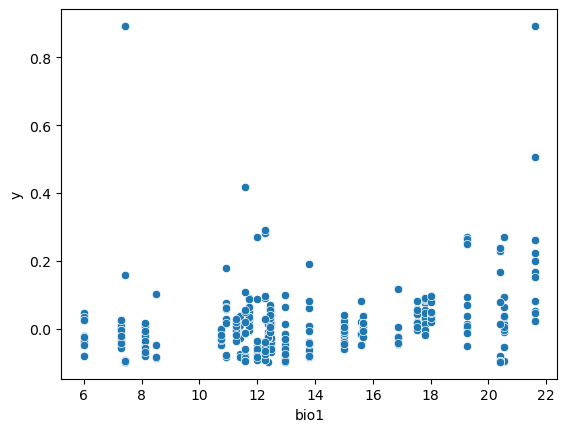

In [71]:
sns.scatterplot(data=lm, x = 'bio1', y = 'y')

<Axes: xlabel='PC1', ylabel='y'>

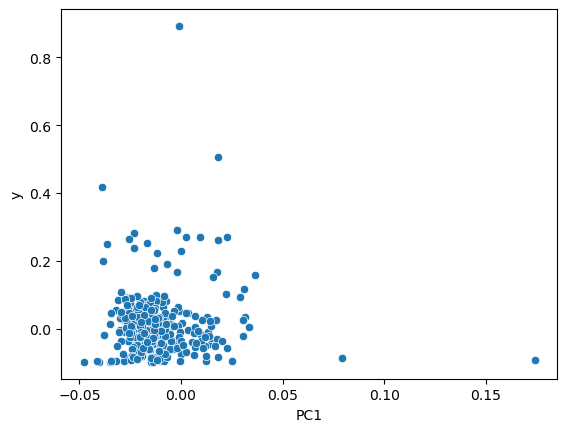

In [59]:
sns.scatterplot(data=lm, x = 'PC1', y = 'y')

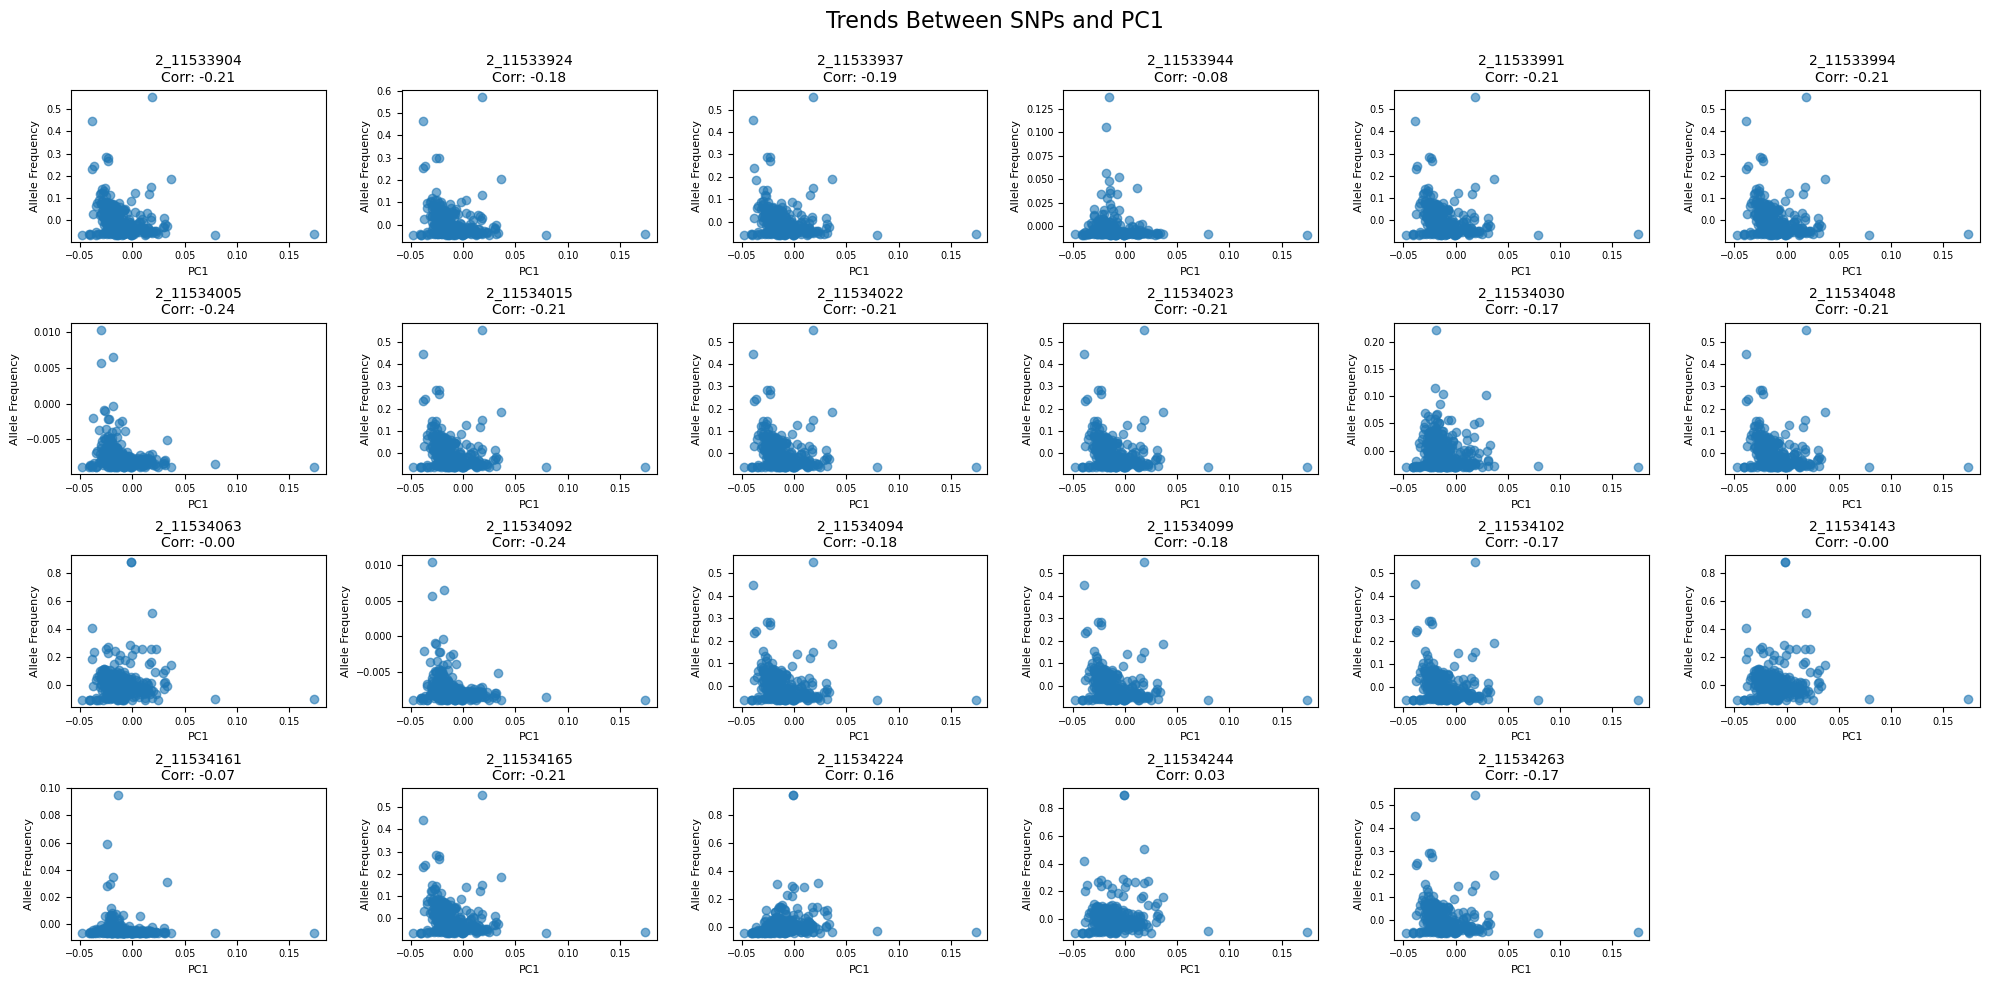

In [49]:
# Create scatterplots for each SNP against PC1 and annotate with correlation values
plt.figure(figsize=(20, 10))
for idx, snp in enumerate(cam5_pop_structure.columns[:-1], 1):  # Exclude PC1 from SNP list
    plt.subplot(4, 6, idx)  # Arrange subplots in a grid (4 rows x 6 columns)
    plt.scatter(cam5_pop_structure['PC1'], cam5_pop_structure[snp], alpha=0.6)
    
    # Calculate correlation between the SNP and PC1
    corr_value = cam5_pop_structure['PC1'].corr(cam5_pop_structure[snp])
    
    # Annotate with the correlation value
    plt.title(f"{snp}\nCorr: {corr_value:.2f}", fontsize=10)
    plt.xlabel('PC1', fontsize=8)
    plt.ylabel('Allele Frequency', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=7)

plt.tight_layout()
plt.suptitle('Trends Between SNPs and PC1', fontsize=16)
plt.subplots_adjust(top=0.9)  # Adjust for title space
plt.show()


In [194]:
delta_p_cam5

,1_1_1,1_1_2,1_1_3,1_1_4,1_1_5,1_1_6,1_1_7,1_1_8,1_1_9,1_1_10,...,60_1_3,60_1_4,60_1_5,60_1_6,60_1_7,60_1_8,60_1_9,60_1_10,60_1_11,60_1_12
id,,,,,,,,,,,,,,,,,,,,,
2_11533904,-0.021280,-0.025936,-0.035706,0.008061,-0.033067,-0.016449,-0.022368,0.000802,0.004066,0.006410,...,-0.056476,0.052150,0.011968,0.123687,-0.030134,0.006912,0.284283,0.006434,0.242403,0.022689
2_11533924,-0.011620,-0.018263,-0.020789,0.009866,-0.019179,-0.007584,-0.010322,0.005781,0.017229,0.013534,...,-0.039691,0.070309,0.002282,0.111082,-0.011271,0.023089,0.299358,0.023747,0.261038,0.040908
2_11533937,-0.015416,-0.020598,-0.030044,0.010735,-0.027222,-0.011391,-0.016674,0.005453,0.008089,0.011468,...,-0.050159,0.004851,0.018415,0.074852,-0.054667,0.013132,0.286269,0.012457,0.184405,-0.007858
2_11533944,-0.006667,-0.001309,0.002436,-0.005825,-0.005858,-0.006012,0.003938,-0.002512,-0.005306,-0.006684,...,-0.008171,0.034076,-0.006730,-0.007642,-0.008785,-0.006677,-0.007164,-0.006324,-0.008099,-0.007325
2_11533991,-0.021280,-0.025936,-0.035706,0.008061,-0.033067,-0.016449,-0.022368,0.000802,0.004066,0.006410,...,-0.056476,0.052150,0.011968,0.123687,-0.030134,0.006912,0.284283,0.006434,0.242403,0.022689
2_11533994,-0.021280,-0.025936,-0.035706,0.008061,-0.033067,-0.016449,-0.022368,0.000802,0.004066,0.006410,...,-0.056476,0.052150,0.011968,0.123687,-0.030134,0.006912,0.284283,0.006434,0.242403,0.022689
2_11534005,-0.007810,-0.007877,-0.007372,-0.003844,-0.007620,-0.007667,-0.007188,-0.007163,-0.007379,-0.007335,...,-0.004953,-0.008736,-0.008719,-0.008514,-0.008508,-0.003495,-0.007213,-0.008466,-0.008388,-0.008154
2_11534015,-0.021280,-0.025936,-0.035706,0.008061,-0.033067,-0.016449,-0.022368,0.000802,0.004066,0.006410,...,-0.056476,0.052150,0.011968,0.123687,-0.030134,0.006912,0.284283,0.006434,0.242403,0.022689
2_11534022,-0.021280,-0.025936,-0.035706,0.008061,-0.033067,-0.016449,-0.022368,0.000802,0.004066,0.006410,...,-0.056476,0.052150,0.011968,0.123687,-0.030134,0.006912,0.284283,0.006434,0.242403,0.022689


In [195]:
pop_structure_first_gen

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
1_1_1,-0.002973,0.005532,0.000684,-0.001404,-0.001962,-0.002770,-0.012940,-0.005790,0.009701,0.002279
1_1_2,-0.020747,0.013771,0.003574,0.000600,-0.014809,0.008086,0.006639,-0.004372,0.000953,0.011947
1_1_3,-0.015614,0.011391,0.005570,-0.005386,0.003615,0.007229,-0.001341,0.000144,0.002477,0.003683
1_1_4,-0.015802,0.001874,-0.005708,-0.012090,-0.001390,0.002428,-0.001453,-0.003403,0.000593,0.005547
1_1_5,-0.023868,0.008038,-0.002085,0.008939,-0.007820,0.005763,0.009710,-0.002877,0.000212,0.002758
...,...,...,...,...,...,...,...,...,...,...
60_1_8,-0.025411,0.011596,-0.019844,0.002377,0.002456,-0.009257,0.012672,-0.018677,0.007851,-0.002802
60_1_9,-0.025633,-0.005403,0.024666,0.022951,-0.014976,-0.040289,-0.022452,0.002144,-0.000436,0.021260
60_1_10,-0.024356,-0.031059,-0.002394,0.034477,-0.032873,-0.027499,-0.013053,0.016492,0.004301,0.015419
60_1_11,-0.036588,-0.037978,-0.030014,0.052480,0.005890,-0.041495,-0.022856,0.022489,0.000789,0.021135


In [ ]:
corr_results = {}
for i in delta_p.index:
    corr_value = delta_p.loc[i, :].corr(pop_structure_first_gen['PC1'])
    corr_results[i] = [corr_value]

In [173]:
pop_structure_first_gen['PC1']

1_1_1     -0.002973
1_1_2     -0.020747
1_1_3     -0.015614
1_1_4     -0.015802
1_1_5     -0.023868
             ...   
60_1_8    -0.025411
60_1_9    -0.025633
60_1_10   -0.024356
60_1_11   -0.036588
60_1_12   -0.031348
Name: PC1, Length: 326, dtype: float64

In [ ]:
combined_df = pd.concat([pcs_df, delta_p_sign_blocks_df], axis=1)


In [ ]:
correlation_matrix = combined_df.corr().loc[pcs_df.columns, delta_p_sign_blocks_df.columns]